# 機械学習の基本コンセプト② パターン発見

## クラスタリング

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
url = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.item'
movie_df= pd.read_csv(url, sep='|', header= None, encoding='latin-1')
movie_df.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [4]:
col_info = " id | movie title | release date | video release date | IMDb URL | unknown | Action | Adventure | Animation | Children's | Comedy | Crime | Documentary | Drama | Fantasy | Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi | Thriller | War | Western "

In [5]:
col_names = col_info.split("|")
movie_df.columns = col_names

In [6]:
movie_df.shape

(1682, 24)

In [7]:
X = movie_df[col_names[5:]]

In [8]:
from sklearn.cluster import KMeans

In [9]:
kmeans = KMeans(n_clusters=4, random_state=0).fit(X)

In [10]:
movie_df['cluster_label'] = kmeans.labels_
movie_df.head()

,id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,cluster_label
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,3
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,2


In [12]:
label_size = movie_df['cluster_label'].value_counts().sort_index()
label_size

cluster_label
0    212
1    107
2    704
3    659
Name: count, dtype: int64

In [13]:
label_size/label_size.sum()

cluster_label
0    0.126040
1    0.063615
2    0.418549
3    0.391795
Name: count, dtype: float64

In [14]:
cluster_genre_df = movie_df[col_names[5:] + ['cluster_label']].groupby('cluster_label').sum().T
cluster_genre_df

cluster_label,0,1,2,3
unknown,0,0,0,2
Action,197,6,32,16
Adventure,77,40,5,13
Animation,3,32,0,7
Children's,3,107,12,0
Comedy,13,41,87,364
Crime,17,0,47,45
Documentary,0,0,3,47
Drama,14,7,704,0
Fantasy,2,12,4,4


In [15]:
cluster_genre_df / cluster_genre_df.sum()

cluster_label,0,1,2,3
unknown,0.000000,0.000000,0.000000,0.002121
Action,0.356239,0.021661,0.028571,0.016967
Adventure,0.139241,0.144404,0.004464,0.013786
Animation,0.005425,0.115523,0.000000,0.007423
Children's,0.005425,0.386282,0.010714,0.000000
Comedy,0.023508,0.148014,0.077679,0.386002
Crime,0.030741,0.000000,0.041964,0.047720
Documentary,0.000000,0.000000,0.002679,0.049841
Drama,0.025316,0.025271,0.628571,0.000000
Fantasy,0.003617,0.043321,0.003571,0.004242


<Axes: xlabel='cluster_label'>

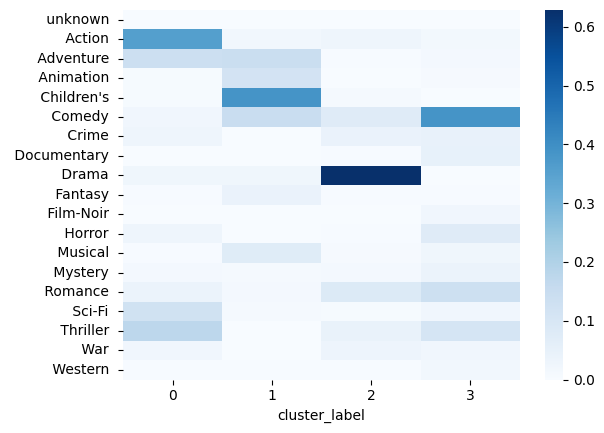

In [16]:
sns.heatmap((cluster_genre_df / cluster_genre_df.sum()), cmap='Blues')